# 🛍️ Customer Segmentation using K-Means Clustering
### Mall Customer Dataset

---

## 📌 What Will You Learn?

By the end of this notebook, you will understand:

- ✅ What is **Unsupervised Learning**?
- ✅ What is **K-Means Clustering**?
- ✅ How to follow a **complete ML Workflow**
- ✅ How to find the **right number of clusters** (Elbow Method)
- ✅ How to **visualize** customer segments

---

## 📂 Dataset Source

**Dataset:** Mall Customer Segmentation Data  
**Link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**About the Dataset:**  
This dataset contains information about customers visiting a shopping mall. The mall wants to understand its customers better — so it can target the right customers with the right marketing strategy.

| Column | Description |
|--------|-------------|
| CustomerID | Unique ID for each customer |
| Gender | Male or Female |
| Age | Age of the customer |
| Annual Income (k$) | Annual income in thousands of dollars |
| Spending Score (1-100) | Score assigned by mall based on spending behavior |

---

## 📚 THEORY: What is Unsupervised Learning?

### Machine Learning has 3 main types:

| Type | Description | Example |
|------|-------------|--------|
| **Supervised Learning** | Learn from labeled data (you know the answer) | Predicting house prices |
| **Unsupervised Learning** | Find patterns in data WITHOUT labels | Grouping customers |
| **Reinforcement Learning** | Learn by trial and error | Chess-playing AI |

### 🔍 Unsupervised Learning — Simple Explanation

> Imagine you have 200 students and you want to group them by their study habits — but **nobody told you** how many groups there are or what those groups should be. You look at their data (sleep hours, study hours, grades) and **find the natural groups yourself**.

**That's unsupervised learning!**

### Common Unsupervised Learning Algorithms:
- 🔵 **K-Means Clustering** ← We will use this today!
- 🔵 DBSCAN
- 🔵 Hierarchical Clustering
- 🔵 PCA (Dimensionality Reduction)

---

## 📚 THEORY: What is K-Means Clustering?

### Simple Explanation:
> K-Means divides your data into **K groups (clusters)** where each data point belongs to the group with the **nearest center (centroid)**.

### How K-Means Works — Step by Step:

```
Step 1: Choose K (number of clusters)
Step 2: Randomly place K centroids in the data
Step 3: Assign each data point to the nearest centroid
Step 4: Move each centroid to the center of its assigned points
Step 5: Repeat Steps 3 & 4 until nothing changes
```

### Real-Life Example:
> Think of K-Means like sorting M&Ms by color. You look at each M&M and put it in the bucket of the closest color. Then you recalculate where the "average" of each bucket is and repeat. Eventually, all M&Ms are sorted!

### Key Terms:
- **K** = number of clusters you want to create
- **Centroid** = the center point of a cluster
- **Inertia** = how spread out the points are within each cluster (lower = better)

---

## 🗺️ Complete ML Workflow

We will follow this step-by-step workflow:

```
1️⃣  Import Libraries
2️⃣  Load Dataset
3️⃣  Exploratory Data Analysis (EDA)
4️⃣  Data Preprocessing
5️⃣  Find Optimal K (Elbow Method)
6️⃣  Train K-Means Model
7️⃣  Visualize Clusters
8️⃣  Interpret Results
```

---

## 1️⃣ Import Libraries

First, we import all the tools (libraries) we need.

| Library | Purpose |
|---------|--------|
| `numpy` | Math operations on arrays |
| `pandas` | Load and manipulate data |
| `matplotlib` | Create plots and charts |
| `seaborn` | Beautiful statistical charts |
| `sklearn` | Machine learning algorithms |

In [13]:
# ============================================================
# STEP 1: IMPORT LIBRARIES
# Think of these as your toolbox — each tool has a purpose!
# ============================================================

import numpy as np                          # For numerical operations
import pandas as pd                         # For loading and exploring data
import matplotlib.pyplot as plt             # For plotting graphs
import seaborn as sns                       # For beautiful visualizations
import warnings
warnings.filterwarnings('ignore')           # Hide unnecessary warnings

# Scikit-learn: The main ML library in Python
from sklearn.cluster import KMeans          # The K-Means algorithm
from sklearn.preprocessing import StandardScaler  # For scaling features
from sklearn.metrics import silhouette_score      # To measure cluster quality

# Make our plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

## 2️⃣ Load Dataset

We load the Mall Customer dataset. 

> 📥 **Download the dataset from Kaggle** and place `Mall_Customers.csv` in the same folder as this notebook.
> 
> **Download Link:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

We also create a **backup copy** of the original data so we can always go back to it.

In [14]:
# ============================================================
# STEP 2: LOAD THE DATASET
# pd.read_csv() reads a CSV file into a DataFrame (like a table)
# ============================================================

# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Save a backup of the original data (good practice!)
df_original = df.copy()

print("✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📊 Shape: 200 rows × 5 columns


---

## 3️⃣ Exploratory Data Analysis (EDA)

### What is EDA?
> EDA means **looking at your data carefully** before doing anything else. It's like reading the instructions before building LEGO — it helps you understand what you're working with!

### EDA Steps:
1. Look at the first few rows
2. Check shape, data types
3. Check for missing values
4. Check basic statistics
5. Visualize distributions

In [15]:
# ============================================================
# EDA STEP 1: Preview the data
# .head() shows the first 5 rows — like opening a spreadsheet!
# ============================================================

print("🔍 First 5 rows of the dataset:")
df.head()

🔍 First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
# ============================================================
# EDA STEP 2: Basic info about the dataset
# .info() tells us data types and if any values are missing
# ============================================================

print("📋 Dataset Information:")
print("-" * 40)
df.info()

📋 Dataset Information:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [17]:
# ============================================================
# EDA STEP 3: Check for missing values
# Missing values can cause errors — always check!
# ============================================================

print("❓ Missing Values in Each Column:")
print("-" * 40)
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\n✅ Great news! No missing values found.")
else:
    print(f"\n⚠️ Total missing values: {missing.sum()} — we need to handle these!")

❓ Missing Values in Each Column:
----------------------------------------
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ Great news! No missing values found.


In [18]:
# ============================================================
# EDA STEP 4: Statistical Summary
# .describe() gives us count, mean, min, max, etc.
# This helps us understand the RANGE of our data
# ============================================================

print("📊 Statistical Summary of Numerical Columns:")
df.describe().round(2)

📊 Statistical Summary of Numerical Columns:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [19]:
# ============================================================
# EDA STEP 5: Check Gender distribution
# value_counts() tells us how many of each category we have
# ============================================================

print("👥 Gender Distribution:")
print(df['Gender'].value_counts())
print(f"\nFemale %: {df['Gender'].value_counts(normalize=True)['Female']*100:.1f}%")
print(f"Male %:   {df['Gender'].value_counts(normalize=True)['Male']*100:.1f}%")

👥 Gender Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64

Female %: 56.0%
Male %:   44.0%


---

## 🔭 3b. Pre-Clustering Visualizations — What Does the Raw Data Look Like?

> **Why look before clustering?**  
> Before we run K-Means, we should **visually explore** how our features relate to each other.  
> This helps us:
> - Get a **feel for the natural groupings** in the data
> - Decide **which features** are most useful for clustering
> - Set **realistic expectations** for how many clusters exist
>
> 🧠 **Think of it like this:** Before sorting a deck of cards, you spread them out on the table to see what you're working with!

---


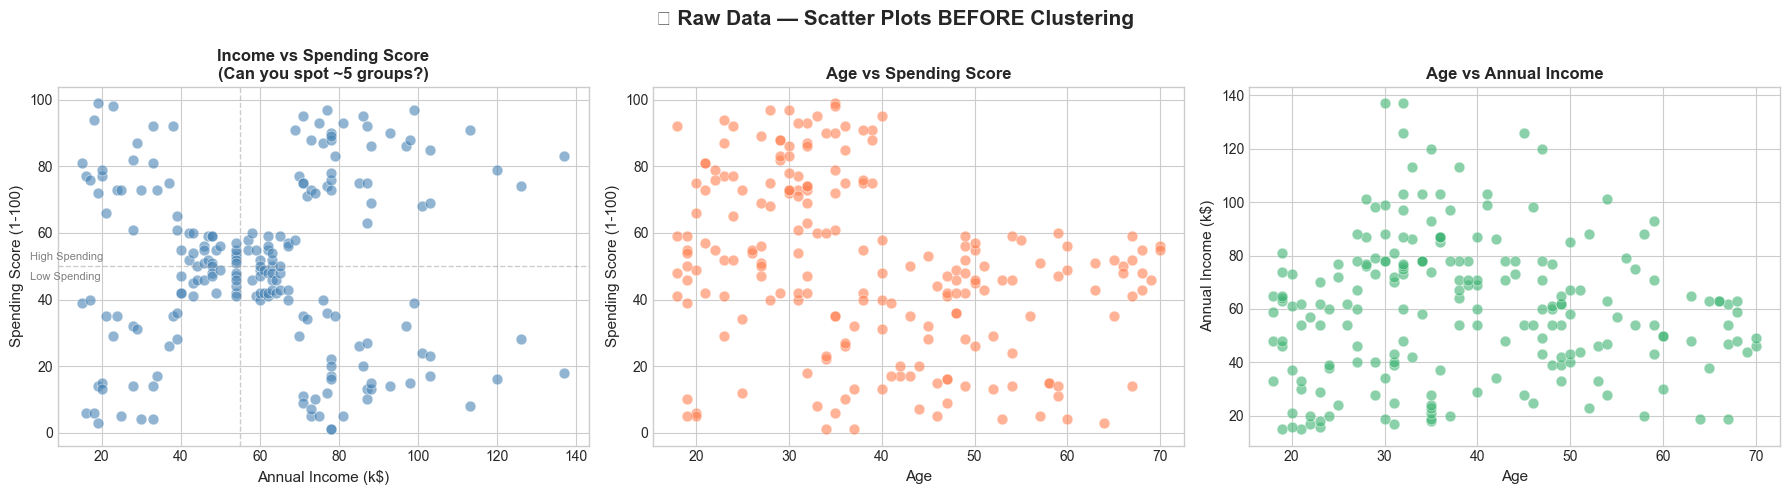

💡 OBSERVATION:
   • In 'Income vs Spending Score', can you see ~5 natural groups?
   • Top-right: High income + High spending
   • Bottom-right: High income + Low spending
   • Top-left: Low income + High spending
   • Bottom-left: Low income + Low spending
   • Middle: Average everything

   K-Means will find these groups automatically — even in higher dimensions!


In [20]:
# ============================================================
# PRE-CLUSTERING: Raw Scatter Plots (BEFORE K-Means)
# We visualize the data AS-IS — no labels, no clusters yet!
# This helps us spot natural groupings with our own eyes.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🔭 Raw Data — Scatter Plots BEFORE Clustering', fontsize=15, fontweight='bold')

# --- Plot 1: Annual Income vs Spending Score (the MAIN clustering feature pair) ---
axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                color='steelblue', alpha=0.6, s=60, edgecolors='white', linewidths=0.5)
axes[0].set_title('Income vs Spending Score\n(Can you spot ~5 groups?)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)', fontsize=11)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=11)
# Add reference lines so students can visually "split" the data
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axvline(x=55, color='gray', linestyle='--', alpha=0.4, linewidth=1)
axes[0].text(2, 52, 'High Spending', fontsize=8, color='gray')
axes[0].text(2, 46, 'Low Spending', fontsize=8, color='gray')

# --- Plot 2: Age vs Spending Score ---
axes[1].scatter(df['Age'], df['Spending Score (1-100)'],
                color='coral', alpha=0.6, s=60, edgecolors='white', linewidths=0.5)
axes[1].set_title('Age vs Spending Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=11)

# --- Plot 3: Age vs Annual Income ---
axes[2].scatter(df['Age'], df['Annual Income (k$)'],
                color='mediumseagreen', alpha=0.6, s=60, edgecolors='white', linewidths=0.5)
axes[2].set_title('Age vs Annual Income', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age', fontsize=11)
axes[2].set_ylabel('Annual Income (k$)', fontsize=11)

plt.tight_layout()
plt.savefig('pre_clustering_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 OBSERVATION:")
print("   • In 'Income vs Spending Score', can you see ~5 natural groups?")
print("   • Top-right: High income + High spending")
print("   • Bottom-right: High income + Low spending")
print("   • Top-left: Low income + High spending")
print("   • Bottom-left: Low income + Low spending")
print("   • Middle: Average everything")
print("\n   K-Means will find these groups automatically — even in higher dimensions!")


---

### 👥 Pre-Clustering: Income vs Spending — Split by Gender

Let's also check if **gender plays a role** in the spending behaviour before clustering.


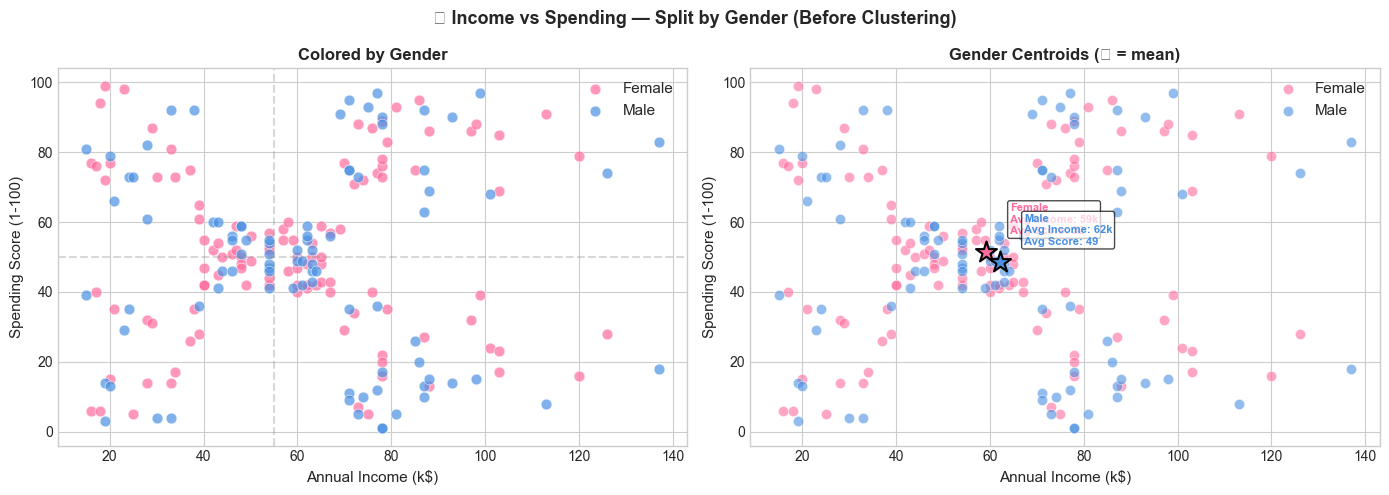

📊 Gender Comparison:
   Female — Avg Income: 59.2k | Avg Spending: 51.5
   Male   — Avg Income: 62.2k | Avg Spending: 48.5

💡 Observation: Gender shows SIMILAR spending patterns overall.
   K-Means will find clusters based on Income & Spending — not gender.


In [21]:
# ============================================================
# PRE-CLUSTERING: Gender-Split Scatter Plot
# Do Male and Female customers show different patterns?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('👥 Income vs Spending — Split by Gender (Before Clustering)', fontsize=13, fontweight='bold')

# --- Plot 1: All customers colored by Gender ---
colors_gender = {'Female': '#FF6B9D', 'Male': '#4A90E2'}
for gender, color in colors_gender.items():
    mask = df['Gender'] == gender
    axes[0].scatter(df.loc[mask, 'Annual Income (k$)'],
                    df.loc[mask, 'Spending Score (1-100)'],
                    c=color, alpha=0.7, s=60, label=gender,
                    edgecolors='white', linewidths=0.5)
axes[0].set_title('Colored by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)', fontsize=11)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=55, color='gray', linestyle='--', alpha=0.3)

# --- Plot 2: Side-by-side subplots per gender ---
for idx, (gender, color) in enumerate(colors_gender.items()):
    subset = df[df['Gender'] == gender]
    axes[1].scatter(subset['Annual Income (k$)'],
                    subset['Spending Score (1-100)'],
                    c=color, alpha=0.6, s=55, label=gender,
                    edgecolors='white', linewidths=0.5)
    # Mark the centroid of each gender group
    cx = subset['Annual Income (k$)'].mean()
    cy = subset['Spending Score (1-100)'].mean()
    axes[1].scatter(cx, cy, s=250, c=color, marker='*',
                    edgecolors='black', linewidths=1.5, zorder=5)
    axes[1].annotate(f'{gender}\nAvg Income: {cx:.0f}k\nAvg Score: {cy:.0f}',
                     xy=(cx, cy), xytext=(cx + 5, cy + 5),
                     fontsize=8, color=color, fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

axes[1].set_title('Gender Centroids (★ = mean)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)', fontsize=11)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=11)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('gender_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Print observations
female_df = df[df['Gender'] == 'Female']
male_df   = df[df['Gender'] == 'Male']
print("📊 Gender Comparison:")
print(f"   Female — Avg Income: {female_df['Annual Income (k$)'].mean():.1f}k | Avg Spending: {female_df['Spending Score (1-100)'].mean():.1f}")
print(f"   Male   — Avg Income: {male_df['Annual Income (k$)'].mean():.1f}k | Avg Spending: {male_df['Spending Score (1-100)'].mean():.1f}")
print("\n💡 Observation: Gender shows SIMILAR spending patterns overall.")
print("   K-Means will find clusters based on Income & Spending — not gender.")


---

### 📐 Pre-Clustering: Pairplot — All Feature Combinations at Once

A **pairplot** shows every possible pair of features simultaneously.  
This is a powerful EDA tool to spot correlations and natural groupings.


---

> ### 🎯 Pre-Clustering Insight Summary
>
> From our visual exploration, we can already **guess** there are approximately **5 natural groups** in the data when looking at **Income vs Spending Score**:
>
> | Guess | Income | Spending |
> |-------|--------|----------|
> | Group A | High | High |
> | Group B | High | Low |
> | Group C | Low | High |
> | Group D | Low | Low |
> | Group E | Medium | Medium |
>
> **K-Means will now confirm this automatically!** Let's move to preprocessing.

---


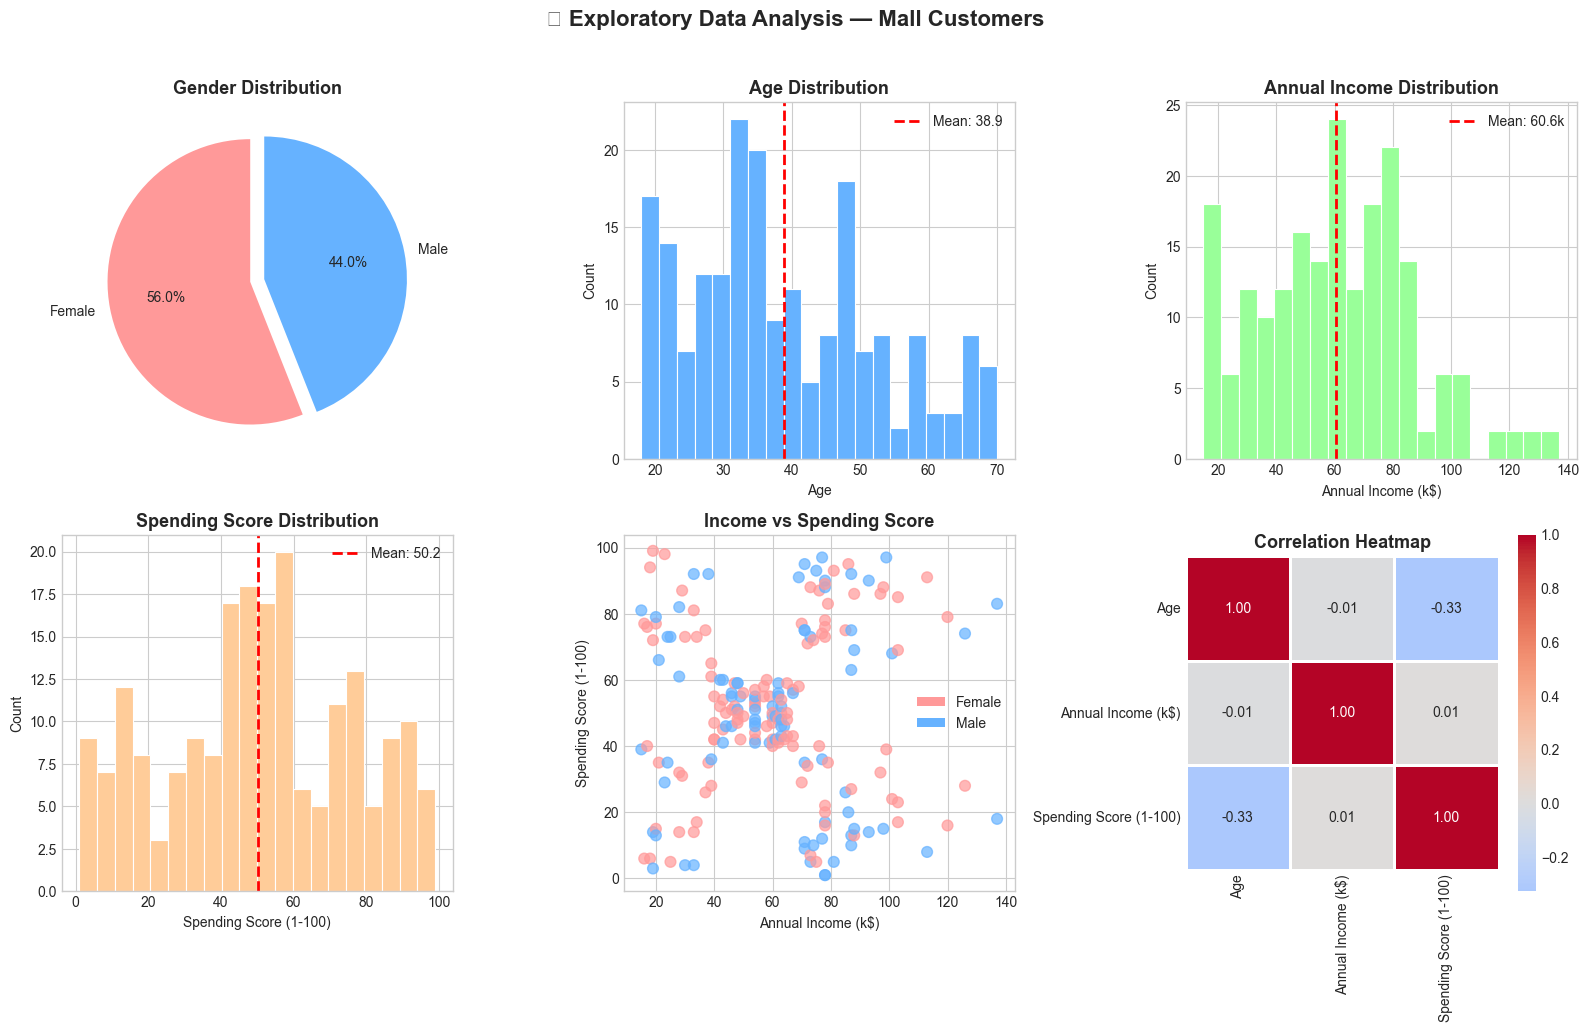


✅ EDA Visualization complete!


In [22]:
# ============================================================
# EDA STEP 6: VISUALIZATIONS
# Charts make it MUCH easier to understand data!
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Exploratory Data Analysis — Mall Customers', fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Gender Distribution (Pie Chart) ---
gender_counts = df['Gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
               colors=['#FF9999', '#66B2FF'], startangle=90, explode=(0.05, 0.05))
axes[0, 0].set_title('Gender Distribution', fontsize=13, fontweight='bold')

# --- Plot 2: Age Distribution (Histogram) ---
axes[0, 1].hist(df['Age'], bins=20, color='#66B2FF', edgecolor='white', linewidth=0.8)
axes[0, 1].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0, 1].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# --- Plot 3: Annual Income Distribution ---
axes[0, 2].hist(df['Annual Income (k$)'], bins=20, color='#99FF99', edgecolor='white', linewidth=0.8)
axes[0, 2].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df["Annual Income (k$)"].mean():.1f}k')
axes[0, 2].set_title('Annual Income Distribution', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Annual Income (k$)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# --- Plot 4: Spending Score Distribution ---
axes[1, 0].hist(df['Spending Score (1-100)'], bins=20, color='#FFCC99', edgecolor='white', linewidth=0.8)
axes[1, 0].axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {df["Spending Score (1-100)"].mean():.1f}')
axes[1, 0].set_title('Spending Score Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Spending Score (1-100)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# --- Plot 5: Income vs Spending Score (Scatter) ---
colors = ['#FF9999' if g == 'Female' else '#66B2FF' for g in df['Gender']]
axes[1, 1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                   c=colors, alpha=0.7, s=60)
axes[1, 1].set_title('Income vs Spending Score', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score (1-100)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF9999', label='Female'), Patch(facecolor='#66B2FF', label='Male')]
axes[1, 1].legend(handles=legend_elements)

# --- Plot 6: Correlation Heatmap ---
numeric_cols = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1, 2], square=True, linewidths=1)
axes[1, 2].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ EDA Visualization complete!")

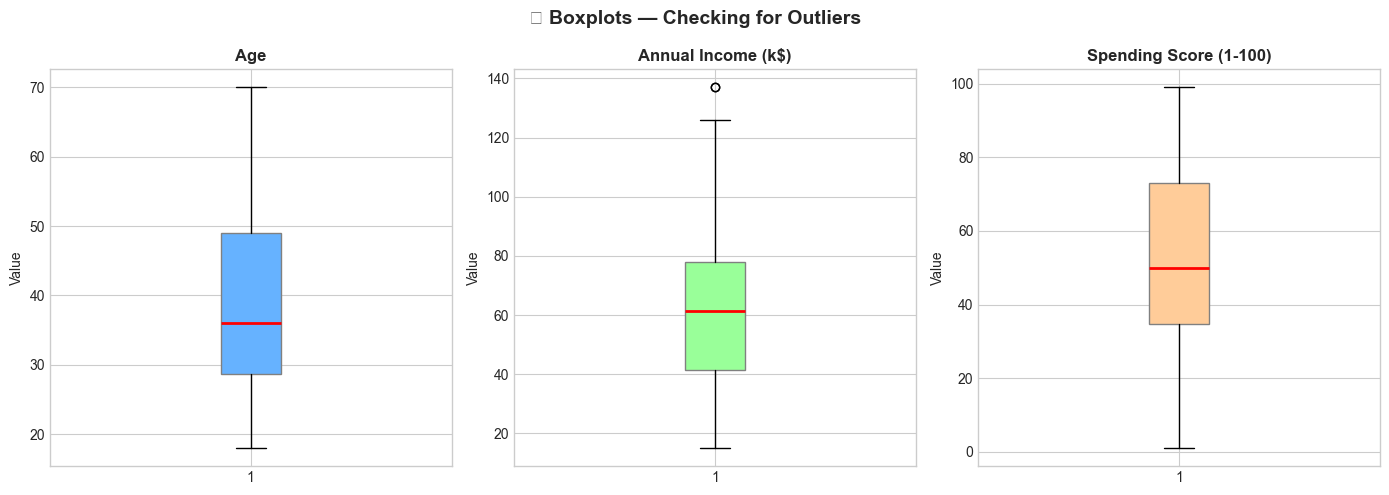

💡 Tip: Dots above/below the whiskers are potential outliers.
   For clustering, outliers may create their own small clusters.


In [23]:
# ============================================================
# EDA STEP 7: Boxplots — Spot Outliers
# A boxplot shows the spread of data and any extreme values
# The 'whiskers' show the normal range, dots are outliers
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('📦 Boxplots — Checking for Outliers', fontsize=14, fontweight='bold')

cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['#66B2FF', '#99FF99', '#FFCC99']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, color='gray'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

print("💡 Tip: Dots above/below the whiskers are potential outliers.")
print("   For clustering, outliers may create their own small clusters.")

---

## 4️⃣ Data Preprocessing

### What is Preprocessing?
> Before training any ML model, we need to **prepare** our data. Raw data is often messy or in a format the algorithm doesn't like.

### Why Do We Scale the Data?

Imagine you have two features:
- **Annual Income**: ranges from 15,000 to 137,000
- **Spending Score**: ranges from 1 to 100

K-Means uses **distance** to group points. If Income is 1000x larger than Spending Score, Income will **dominate** the clustering and ignore Spending Score completely!

**Solution:** Scale all features to the same range using **StandardScaler**.

```
StandardScaler formula:  z = (x - mean) / std_deviation
Result: All features have mean=0 and std=1
```

In [24]:
# ============================================================
# STEP 4: DATA PREPROCESSING
# We select the features we want to cluster on
# ============================================================

# --- 4a: Select Features ---
# We use Annual Income and Spending Score for the main clustering
# These two features are most meaningful for customer segmentation

# Features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

print("📌 Features selected for clustering:")
print("   - Annual Income (k$)")
print("   - Spending Score (1-100)")
print(f"\n📊 Feature shape: {X.shape}")
print("\n🔍 First 5 rows:")
print(X.head())

📌 Features selected for clustering:
   - Annual Income (k$)
   - Spending Score (1-100)

📊 Feature shape: (200, 2)

🔍 First 5 rows:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [25]:
# ============================================================
# 4b: SCALE THE DATA
# StandardScaler makes all features on the same scale
# This is CRITICAL for K-Means to work correctly!
# ============================================================

# Create the scaler
scaler = StandardScaler()

# Fit and transform the data
# fit_transform() learns the mean/std AND transforms in one step
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=['Annual Income (scaled)', 'Spending Score (scaled)'])

print("✅ Data scaled successfully!")
print("\n📊 Before scaling (original):")
print(X.describe().round(2))
print("\n📊 After scaling:")
print(X_scaled_df.describe().round(4))
print("\n💡 Notice: After scaling, mean ≈ 0 and std ≈ 1 for both features")

✅ Data scaled successfully!

📊 Before scaling (original):
       Annual Income (k$)  Spending Score (1-100)
count              200.00                  200.00
mean                60.56                   50.20
std                 26.26                   25.82
min                 15.00                    1.00
25%                 41.50                   34.75
50%                 61.50                   50.00
75%                 78.00                   73.00
max                137.00                   99.00

📊 After scaling:
       Annual Income (scaled)  Spending Score (scaled)
count                200.0000                 200.0000
mean                  -0.0000                  -0.0000
std                    1.0025                   1.0025
min                   -1.7390                  -1.9100
25%                   -0.7275                  -0.5998
50%                    0.0359                  -0.0078
75%                    0.6657                   0.8851
max                    2.9177     

---

## 5️⃣ Finding the Optimal K — The Elbow Method

### The Big Question: How Many Clusters Should We Use?

> This is the most important step in K-Means! We need to decide **K** (the number of clusters).

### The Elbow Method:
We train K-Means for K = 1, 2, 3, ... 10 and measure **inertia** each time.

- **Inertia** = sum of distances from each point to its cluster center
- **Lower inertia = tighter clusters** (but more K = always lower, so we can't just minimize it)

We look for the **"elbow"** — the point where adding more clusters stops helping much.

```
Inertia
  |\  
  | \ 
  |  \       ← Elbow here!
  |   \_______________
  |_________________________ K
```

In [26]:
# ============================================================
# STEP 5: ELBOW METHOD
# Train K-Means for K = 1 to 10 and record inertia
# ============================================================

inertia_values = []        # Store inertia for each K
silhouette_values = []     # Store silhouette score for each K
K_range = range(2, 11)     # We test K from 2 to 10
    
print("🔄 Training K-Means for K = 2 to 10...")
print("-" * 45)
print(f"{'K':>5} | {'Inertia':>12} | {'Silhouette Score':>17}")
print("-" * 45)

for k in K_range:
    # Train K-Means with k clusters
    # n_init=10 means try 10 different random starts (picks the best)
    # random_state=42 for reproducibility (same result every run)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    
    # Record inertia (for Elbow Method)
    inertia_values.append(kmeans.inertia_)  
    
    # Record silhouette score (another quality measure)
    # Silhouette: how well-separated the clusters are (-1 to 1, higher = better)
    labels = kmeans.labels_
    sil = silhouette_score(X_scaled, labels)
    silhouette_values.append(sil)
    
    print(f"  K={k:>2} | Inertia: {kmeans.inertia_:>10.2f} | Silhouette: {sil:>8.4f}")

print("-" * 45)
best_k_sil = K_range[silhouette_values.index(max(silhouette_values))]
print(f"\n🏆 Best K by Silhouette Score: K = {best_k_sil}")

🔄 Training K-Means for K = 2 to 10...
---------------------------------------------
    K |      Inertia |  Silhouette Score
---------------------------------------------
  K= 2 | Inertia:     269.69 | Silhouette:   0.3213
  K= 3 | Inertia:     157.70 | Silhouette:   0.4666
  K= 4 | Inertia:     108.92 | Silhouette:   0.4939
  K= 5 | Inertia:      65.57 | Silhouette:   0.5547
  K= 6 | Inertia:      55.06 | Silhouette:   0.5399
  K= 7 | Inertia:      44.86 | Silhouette:   0.5281
  K= 8 | Inertia:      37.23 | Silhouette:   0.4552
  K= 9 | Inertia:      32.39 | Silhouette:   0.4571
  K=10 | Inertia:      29.98 | Silhouette:   0.4432
---------------------------------------------

🏆 Best K by Silhouette Score: K = 5


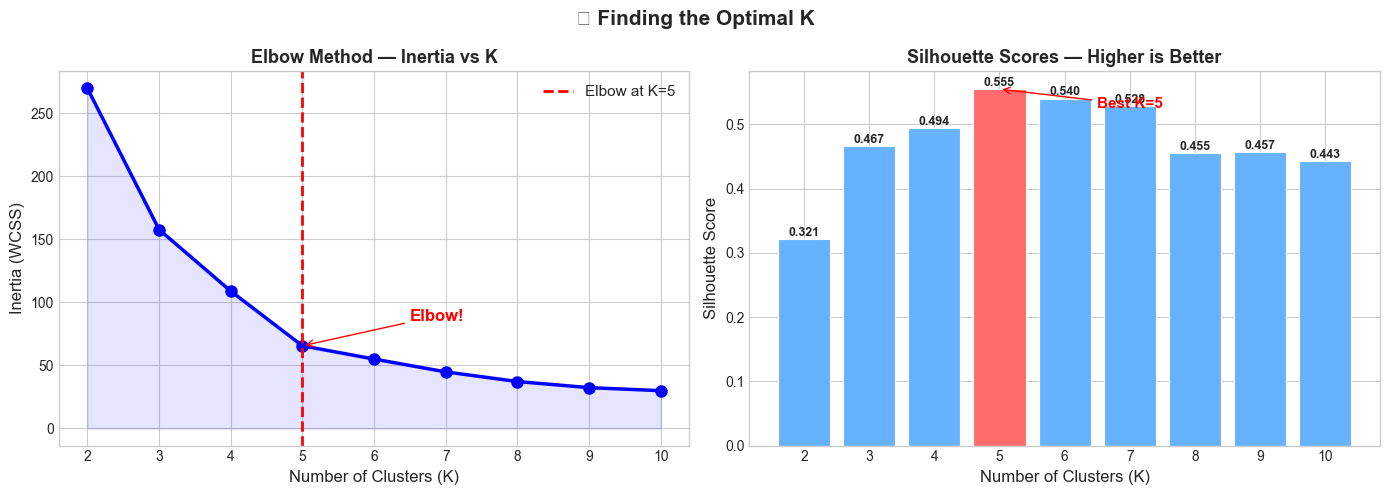


💡 INTERPRETATION:
   • Elbow Method suggests K = 5 (where the curve bends sharply)
   • Silhouette Score confirms K = 5 (highest score = best separation)
   • We will use K = 5 for our final model


In [27]:
# ============================================================
# VISUALIZE: Elbow Curve + Silhouette Scores
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🔍 Finding the Optimal K', fontsize=15, fontweight='bold')

# --- Plot 1: Elbow Curve ---
axes[0].plot(list(K_range), inertia_values, 'bo-', linewidth=2.5, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Elbow at K=5')
axes[0].fill_between(list(K_range), inertia_values, alpha=0.1, color='blue')
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(K_range))

# Annotate the elbow point
elbow_idx = list(K_range).index(5)
axes[0].annotate('Elbow!', xy=(5, inertia_values[elbow_idx]),
                xytext=(6.5, inertia_values[elbow_idx] + 20),
                fontsize=12, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))

# --- Plot 2: Silhouette Scores ---
axes[1].bar(list(K_range), silhouette_values, color=['#FF6B6B' if k == best_k_sil else '#66B2FF' for k in K_range],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('Silhouette Scores — Higher is Better', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(list(K_range))

# Add value labels on bars
for i, (k, v) in enumerate(zip(K_range, silhouette_values)):
    axes[1].text(k, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1].annotate(f'Best K={best_k_sil}', xy=(best_k_sil, max(silhouette_values)),
                xytext=(best_k_sil + 1.5, max(silhouette_values) - 0.03),
                fontsize=11, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 INTERPRETATION:")
print("   • Elbow Method suggests K = 5 (where the curve bends sharply)")
print(f"   • Silhouette Score confirms K = {best_k_sil} (highest score = best separation)")
print("   • We will use K = 5 for our final model")

---

## 6️⃣ Train the Final K-Means Model

Now that we know **K = 5** is optimal, let's train the final model!

### What happens after training?
Each customer gets assigned a **cluster label** (0, 1, 2, 3, or 4) telling us which group they belong to.

In [28]:
# ============================================================
# STEP 6: TRAIN THE FINAL K-MEANS MODEL
# We use K=5 based on our analysis above
# ============================================================

# Set the optimal number of clusters
OPTIMAL_K = 5

# Train the final model
# n_init=10 → try 10 different starting points and pick the best
# random_state=42 → makes results reproducible
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
kmeans_final.fit(X_scaled)

# Get cluster assignments for each customer
# Each customer gets a number: 0, 1, 2, 3, or 4
df['Cluster'] = kmeans_final.labels_

# Get the cluster centers (centroids) — in original scale
# inverse_transform converts scaled values back to original values
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original,
                             columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroids_df.index.name = 'Cluster'

print(f"✅ K-Means model trained with K = {OPTIMAL_K} clusters!")
print(f"\n📊 Cluster assignments added to dataset.")
print(f"   Unique clusters: {sorted(df['Cluster'].unique())}")
print(f"\n🎯 Cluster Centroids (Original Scale):")
print(centroids_df.round(2))

✅ K-Means model trained with K = 5 clusters!

📊 Cluster assignments added to dataset.
   Unique clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)]

🎯 Cluster Centroids (Original Scale):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91


In [29]:
# ============================================================
# Check how many customers are in each cluster
# ============================================================

print("👥 Customers per Cluster:")
print("-" * 35)
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  Cluster {cluster}: {count:>3} customers ({pct:.1f}%) {bar}")
print("-" * 35)
print(f"  Total: {len(df)} customers")

👥 Customers per Cluster:
-----------------------------------
  Cluster 0:  81 customers (40.5%) ████████████████████
  Cluster 1:  39 customers (19.5%) █████████
  Cluster 2:  22 customers (11.0%) █████
  Cluster 3:  35 customers (17.5%) ████████
  Cluster 4:  23 customers (11.5%) █████
-----------------------------------
  Total: 200 customers


---

## 7️⃣ Visualize the Clusters

Let's **see** the clusters! Good visualization helps us understand what the model found.

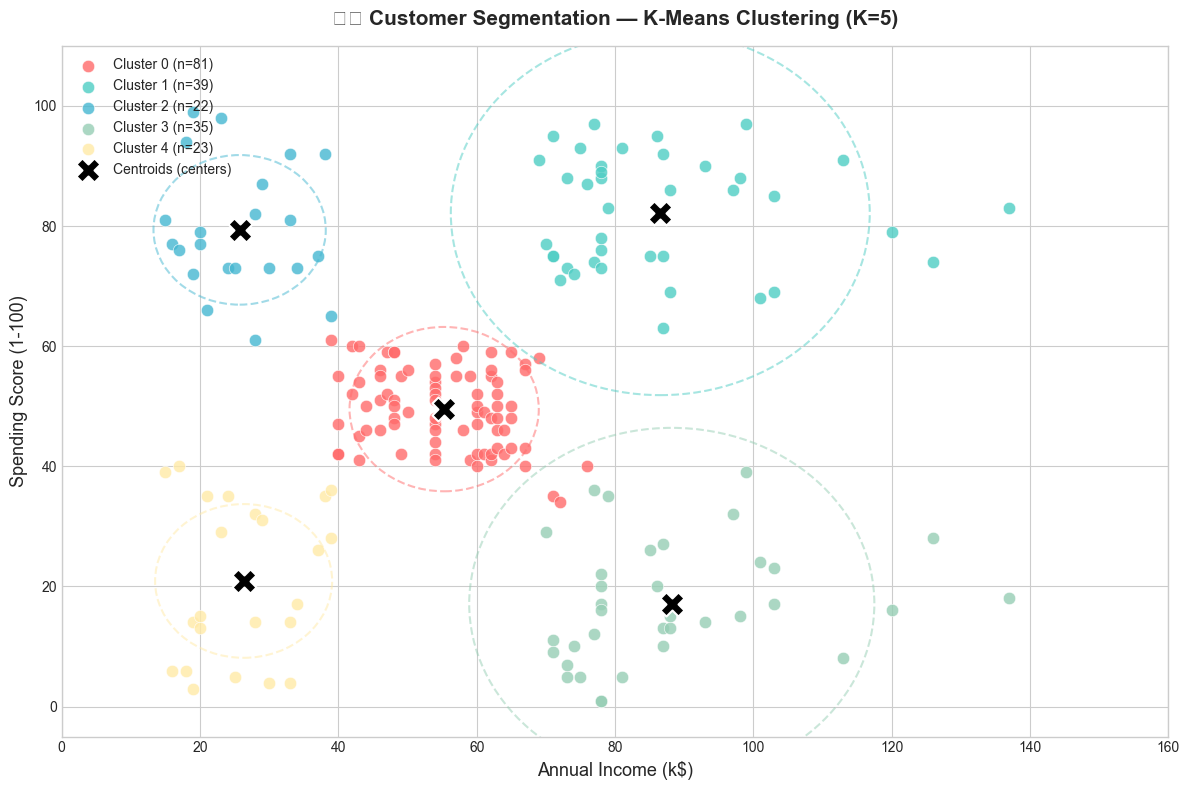

✅ Main cluster visualization complete!


In [30]:
# ============================================================
# STEP 7: MAIN CLUSTER VISUALIZATION
# This is the most important plot!
# ============================================================

# Define colors and descriptive names for each cluster
# (We'll properly name them after analyzing in Step 8)
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
cluster_labels_temp = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each cluster with a different color
for i in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score (1-100)'],
               c=cluster_colors[i], s=80, alpha=0.8,
               label=f'{cluster_labels_temp[i]} (n={len(cluster_data)})',
               edgecolors='white', linewidths=0.5)

# Plot cluster centroids (centers)
ax.scatter(centroids_original[:, 0], centroids_original[:, 1],
           s=300, c='black', marker='X', zorder=5,
           label='Centroids (centers)', edgecolors='white', linewidths=1.5)

# Draw circles around centroids to show cluster boundaries
for i, (cx, cy) in enumerate(centroids_original):
    cluster_data = df[df['Cluster'] == i]
    radius = max(
        ((cluster_data['Annual Income (k$)'] - cx)**2 +
         (cluster_data['Spending Score (1-100)'] - cy)**2).max()**0.5 * 0.6, 5
    )
    circle = plt.Circle((cx, cy), radius, fill=False,
                        color=cluster_colors[i], linestyle='--', linewidth=1.5, alpha=0.5)
    ax.add_patch(circle)

# Labels and styling
ax.set_title('🛍️ Customer Segmentation — K-Means Clustering (K=5)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Annual Income (k$)', fontsize=13)
ax.set_ylabel('Spending Score (1-100)', fontsize=13)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_xlim(0, 160)
ax.set_ylim(-5, 110)

plt.tight_layout()
plt.savefig('clusters_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Main cluster visualization complete!")

---

## 8️⃣ Interpret Results — What Did We Find?

This is the most exciting part! Let's understand **who** each cluster represents.

> 💡 This is where **domain knowledge** matters. We look at the cluster characteristics and give them **meaningful business names**.

In [31]:
# ============================================================
# STEP 8: INTERPRET CLUSTERS
# Calculate mean values for each cluster to understand them
# ============================================================

# Calculate summary statistics for each cluster
cluster_summary = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
    Pct_Female=('Gender', lambda x: (x == 'Female').mean() * 100)
).round(1)

print("📊 Cluster Summary Statistics:")
print("=" * 70)
print(cluster_summary.to_string())
print("=" * 70)

📊 Cluster Summary Statistics:
         Count  Avg_Age  Avg_Income  Avg_Spending  Pct_Female
Cluster                                                      
0           81     42.7        55.3          49.5        59.3
1           39     32.7        86.5          82.1        53.8
2           22     25.3        25.7          79.4        59.1
3           35     41.1        88.2          17.1        45.7
4           23     45.2        26.3          20.9        60.9


In [32]:
# ============================================================
# ASSIGN MEANINGFUL NAMES TO CLUSTERS
# Based on Income and Spending patterns
# ============================================================

# Map cluster numbers to business-friendly names
# (You may need to adjust these based on your cluster summary output)
cluster_names = {
    0: '💛 Careful Spenders (Mid Income, Low Spending)',
    1: '💜 High Value Targets (High Income, High Spending)',
    2: '❤️  Sensible Savers (High Income, Low Spending)',
    3: '💚 Budget Enthusiasts (Low Income, High Spending)',
    4: '💙 Standard Shoppers (Mid Income, Mid Spending)'
}

# Add the readable names to our dataframe
df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print("🏷️  Cluster Names Assigned!")
print("\nHere's what each cluster means:")
print("-" * 60)
for cluster_id, name in cluster_names.items():
    count = len(df[df['Cluster'] == cluster_id])
    summary = cluster_summary.loc[cluster_id]
    print(f"\n{name}")
    print(f"   👥 Customers: {count}")
    print(f"   📅 Avg Age: {summary['Avg_Age']:.0f}")
    print(f"   💰 Avg Income: ${summary['Avg_Income']:.0f}k")
    print(f"   🛒 Avg Spending: {summary['Avg_Spending']:.0f}/100")

🏷️  Cluster Names Assigned!

Here's what each cluster means:
------------------------------------------------------------

💛 Careful Spenders (Mid Income, Low Spending)
   👥 Customers: 81
   📅 Avg Age: 43
   💰 Avg Income: $55k
   🛒 Avg Spending: 50/100

💜 High Value Targets (High Income, High Spending)
   👥 Customers: 39
   📅 Avg Age: 33
   💰 Avg Income: $86k
   🛒 Avg Spending: 82/100

❤️  Sensible Savers (High Income, Low Spending)
   👥 Customers: 22
   📅 Avg Age: 25
   💰 Avg Income: $26k
   🛒 Avg Spending: 79/100

💚 Budget Enthusiasts (Low Income, High Spending)
   👥 Customers: 35
   📅 Avg Age: 41
   💰 Avg Income: $88k
   🛒 Avg Spending: 17/100

💙 Standard Shoppers (Mid Income, Mid Spending)
   👥 Customers: 23
   📅 Avg Age: 45
   💰 Avg Income: $26k
   🛒 Avg Spending: 21/100


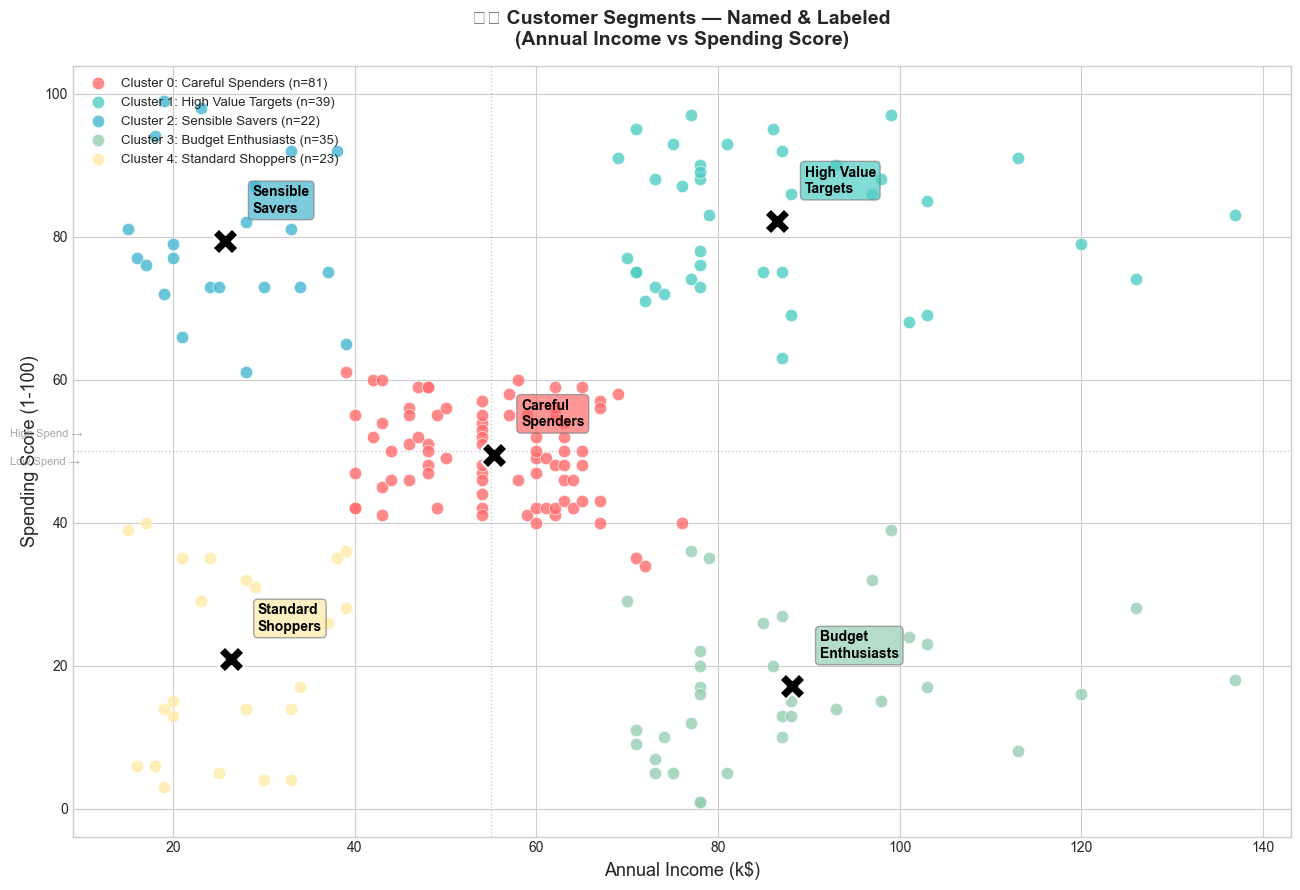


✅ Final labeled cluster plot saved!


In [33]:
# ============================================================
# FINAL VISUALIZATION: Labeled Cluster Plot
# ============================================================

short_names = {
    0: 'Careful\nSpenders',
    1: 'High Value\nTargets',
    2: 'Sensible\nSavers',
    3: 'Budget\nEnthusiasts',
    4: 'Standard\nShoppers'
}

fig, ax = plt.subplots(figsize=(13, 9))

for i in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score (1-100)'],
               c=cluster_colors[i], s=80, alpha=0.8,
               label=f'Cluster {i}: {short_names[i].replace(chr(10), " ")} (n={len(cluster_data)})',
               edgecolors='white', linewidths=0.5, zorder=3)

# Plot and label centroids
for i, (cx, cy) in enumerate(centroids_original):
    ax.scatter(cx, cy, s=350, c='black', marker='X', zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(short_names[i],
                xy=(cx, cy), xytext=(cx + 3, cy + 4),
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors[i],
                          alpha=0.7, edgecolor='gray'),
                zorder=6)

ax.set_title('🛍️ Customer Segments — Named & Labeled\n(Annual Income vs Spending Score)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Income (k$)', fontsize=13)
ax.set_ylabel('Spending Score (1-100)', fontsize=13)
ax.legend(loc='upper left', fontsize=9.5, framealpha=0.9)

# Add quadrant lines for reference
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.4, linewidth=1)
ax.axvline(x=55, color='gray', linestyle=':', alpha=0.4, linewidth=1)
ax.text(2, 52, 'High Spend →', fontsize=8, color='gray', alpha=0.7)
ax.text(2, 48, 'Low Spend →', fontsize=8, color='gray', alpha=0.7)

plt.tight_layout()
plt.savefig('clusters_final_labeled.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Final labeled cluster plot saved!")

---

## 📋 Final Summary: What Did We Find?

We identified **5 distinct customer segments** in the mall:

| Segment | Income | Spending | Strategy |
|---------|--------|----------|----------|
| 💛 Careful Spenders | Medium | Low | Offer discounts/loyalty programs |
| 💜 High Value Targets | High | High | Premium products, VIP treatment |
| ❤️ Sensible Savers | High | Low | Show value, highlight deals |
| 💚 Budget Enthusiasts | Low | High | Budget-friendly promotions |
| 💙 Standard Shoppers | Medium | Medium | General promotions |

> 🎯 **Business Impact:** Instead of sending the same advertisement to ALL 200 customers, the mall can now send **personalized messages** to each segment — increasing sales and customer satisfaction!

In [34]:
# ============================================================
# FINAL SUMMARY STATISTICS
# ============================================================

print("=" * 55)
print("        📊 FINAL MODEL SUMMARY")
print("=" * 55)
print(f"  Algorithm       : K-Means Clustering")
print(f"  Dataset         : Mall Customer Segmentation")
print(f"  Total Customers : {len(df)}")
print(f"  Features Used   : Annual Income, Spending Score")
print(f"  Optimal K       : {OPTIMAL_K} clusters")
print(f"  Final Inertia   : {kmeans_final.inertia_:.2f}")
final_sil = silhouette_score(X_scaled, kmeans_final.labels_)
print(f"  Silhouette Score: {final_sil:.4f} (higher is better)")
print("=" * 55)
print("\n🎉 Congratulations! You completed a full ML workflow!")
print("\n✅ Steps completed:")
steps = [
    "Imported libraries",
    "Loaded and saved dataset",
    "Performed EDA (5+ visualizations)",
    "Preprocessed data (feature selection + scaling)",
    "Found optimal K using Elbow + Silhouette",
    "Trained final K-Means model",
    "Visualized clusters",
    "Interpreted and named each segment"
]
for step in steps:
    print(f"   ✓ {step}")

        📊 FINAL MODEL SUMMARY
  Algorithm       : K-Means Clustering
  Dataset         : Mall Customer Segmentation
  Total Customers : 200
  Features Used   : Annual Income, Spending Score
  Optimal K       : 5 clusters
  Final Inertia   : 65.57
  Silhouette Score: 0.5547 (higher is better)

🎉 Congratulations! You completed a full ML workflow!

✅ Steps completed:
   ✓ Imported libraries
   ✓ Loaded and saved dataset
   ✓ Performed EDA (5+ visualizations)
   ✓ Preprocessed data (feature selection + scaling)
   ✓ Found optimal K using Elbow + Silhouette
   ✓ Trained final K-Means model
   ✓ Visualized clusters
   ✓ Interpreted and named each segment


In [35]:
# ============================================================
# SAVE THE RESULTS
# Save the clustered dataset so you can use it later!
# ============================================================

# Save the final dataset with cluster assignments
output_filename = 'Mall_Customers_Clustered1.csv'

df.to_csv(output_filename, index=False)

print(f"💾 Results saved to: '{output_filename}'")
print(f"\n🔍 Preview of saved file:")
df[['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
    'Spending Score (1-100)', 'Cluster', 'Cluster_Name']].head(10)

💾 Results saved to: 'Mall_Customers_Clustered1.csv'

🔍 Preview of saved file:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster_Name
0,1,Male,19,15,39,4,"💙 Standard Shoppers (Mid Income, Mid Spending)"
1,2,Male,21,15,81,2,"❤️ Sensible Savers (High Income, Low Spending)"
2,3,Female,20,16,6,4,"💙 Standard Shoppers (Mid Income, Mid Spending)"
3,4,Female,23,16,77,2,"❤️ Sensible Savers (High Income, Low Spending)"
4,5,Female,31,17,40,4,"💙 Standard Shoppers (Mid Income, Mid Spending)"
5,6,Female,22,17,76,2,"❤️ Sensible Savers (High Income, Low Spending)"
6,7,Female,35,18,6,4,"💙 Standard Shoppers (Mid Income, Mid Spending)"
7,8,Female,23,18,94,2,"❤️ Sensible Savers (High Income, Low Spending)"
8,9,Male,64,19,3,4,"💙 Standard Shoppers (Mid Income, Mid Spending)"
9,10,Female,30,19,72,2,"❤️ Sensible Savers (High Income, Low Spending)"


---

# 🔮 Step 9: Predicting New / Unseen Customers

> ### The Big Question: Can we predict which group a NEW customer belongs to?
>
> Yes! Once the K-Means model is trained, we can use it to **predict** which cluster any new customer falls into — even someone who was not in the original dataset.
>
> This is extremely useful in the real world:
> - A new customer signs up → instantly know their segment
> - A sales team can immediately personalise their approach
> - No need to re-train the model every time!
>
> ### How does prediction work in K-Means?
>
> ```
> New customer data
>        ↓
> Apply the SAME scaler (transform only — do NOT fit again!)
>        ↓
> Feed scaled data into the trained K-Means model
>        ↓
> model.predict() → returns the nearest cluster number
>        ↓
> Map cluster number → cluster name
> ```
>
> > ⚠️ **Critical rule:** When predicting, we use `scaler.transform()` NOT `scaler.fit_transform()`.
> > `fit_transform` would learn new statistics from the new data and break the scaling.
> > `transform` applies the SAME scaling the model was trained on.

---


## 9a. Build a Reusable Prediction Function

We will write a clean `predict_customer()` function that:
1. Takes a customer's income and spending score as input
2. Scales them using the **already-fitted** scaler
3. Predicts the cluster using the **already-trained** model
4. Returns a full, readable result


In [37]:
# ============================================================
# STEP 9a: PREDICTION FUNCTION
# This function predicts which cluster a NEW customer belongs to.
# It reuses the already-trained: scaler + kmeans_final + cluster_names
# ============================================================

def predict_customer(annual_income, spending_score, verbose=True):
    """
    Predict which customer segment a new person belongs to.

    Parameters:
    -----------
    annual_income  : float → Annual income of the customer in k$ (e.g. 75 means $75,000)
    spending_score : float → Spending score assigned by the mall (1 to 100)
    verbose        : bool  → If True, print a detailed result (default: True)

    Returns:
    --------
    dict with keys: cluster_id, cluster_name, income, spending_score
    """

    # ── Step 1: Validate inputs ──────────────────────────────────────────────
    # Give helpful error messages if the input values are out of range
    if not (0 < annual_income < 200):
        print("⚠️  Warning: Annual income seems unusual. Expected range: 15–137 k$")
    if not (1 <= spending_score <= 100):
        raise ValueError("❌ Spending score must be between 1 and 100!")

    # ── Step 2: Create a small DataFrame for the new customer ────────────────
    # We use a DataFrame (not just a list) so column names match the scaler
    new_customer = pd.DataFrame({
        'Annual Income (k$)':    [annual_income],
        'Spending Score (1-100)': [spending_score]
    })

    # ── Step 3: Scale the new data using the SAME scaler ─────────────────────
    # IMPORTANT: use .transform() NOT .fit_transform()
    # .transform() applies the scaling rules learned from the TRAINING data
    new_customer_scaled = scaler.transform(new_customer)

    # ── Step 4: Predict the cluster ──────────────────────────────────────────
    # .predict() finds the nearest centroid and returns the cluster number
    cluster_id = kmeans_final.predict(new_customer_scaled)[0]

    # ── Step 5: Get the human-readable cluster name ──────────────────────────
    cluster_name = cluster_names[cluster_id]

    # ── Step 6: Print a detailed result ──────────────────────────────────────
    if verbose:
        print("=" * 55)
        print("       🔮 CUSTOMER SEGMENT PREDICTION")
        print("=" * 55)
        print(f"  💰 Annual Income   : ${annual_income}k")
        print(f"  🛒 Spending Score  : {spending_score}/100")
        print(f"  🏷️  Cluster ID     : {cluster_id}")
        print(f"  📌 Segment         : {cluster_name}")
        print("=" * 55)

        # Show centroid comparison so student understands WHY this cluster was chosen
        print("\n📍 Distance to each cluster centroid:")
        print("-" * 45)
        for cid, (cx, cy) in enumerate(centroids_original):
            dist = ((annual_income - cx)**2 + (spending_score - cy)**2) ** 0.5
            marker = " ← NEAREST (predicted)" if cid == cluster_id else ""
            print(f"  Cluster {cid} | Income:{cx:6.1f}k  Score:{cy:5.1f} | dist={dist:6.1f}{marker}")
        print("-" * 45)

    # ── Step 7: Return a dictionary with all the results ─────────────────────
    return {
        'cluster_id':   cluster_id,
        'cluster_name': cluster_name,
        'income':       annual_income,
        'spending_score': spending_score
    }

print("✅ predict_customer() function is ready!")
print("\n📖 Usage:")
print('   predict_customer(annual_income=75, spending_score=80)')
print('   predict_customer(annual_income=30, spending_score=10)')


✅ predict_customer() function is ready!

📖 Usage:
   predict_customer(annual_income=75, spending_score=80)
   predict_customer(annual_income=30, spending_score=10)


---

## 9b. Predict Individual Customers

Let's test our function on a few example customers and understand why each prediction makes sense.


In [38]:
# ============================================================
# STEP 9b: PREDICT INDIVIDUAL CUSTOMERS
# Test with different types of people to see the model working
# ============================================================

print("\n" + "="*60)
print("  EXAMPLE 1: High-income, high-spending young professional")
print("="*60)
result1 = predict_customer(annual_income=90, spending_score=85)

print("\n" + "="*60)
print("  EXAMPLE 2: High-income but very careful spender")
print("="*60)
result2 = predict_customer(annual_income=95, spending_score=10)

print("\n" + "="*60)
print("  EXAMPLE 3: Low income but loves to spend")
print("="*60)
result3 = predict_customer(annual_income=20, spending_score=78)

print("\n" + "="*60)
print("  EXAMPLE 4: Average everything — typical shopper")
print("="*60)
result4 = predict_customer(annual_income=55, spending_score=50)



  EXAMPLE 1: High-income, high-spending young professional
       🔮 CUSTOMER SEGMENT PREDICTION
  💰 Annual Income   : $90k
  🛒 Spending Score  : 85/100
  🏷️  Cluster ID     : 1
  📌 Segment         : 💜 High Value Targets (High Income, High Spending)

📍 Distance to each cluster centroid:
---------------------------------------------
  Cluster 0 | Income:  55.3k  Score: 49.5 | dist=  49.6
  Cluster 1 | Income:  86.5k  Score: 82.1 | dist=   4.5 ← NEAREST (predicted)
  Cluster 2 | Income:  25.7k  Score: 79.4 | dist=  64.5
  Cluster 3 | Income:  88.2k  Score: 17.1 | dist=  67.9
  Cluster 4 | Income:  26.3k  Score: 20.9 | dist=  90.4
---------------------------------------------

  EXAMPLE 2: High-income but very careful spender
       🔮 CUSTOMER SEGMENT PREDICTION
  💰 Annual Income   : $95k
  🛒 Spending Score  : 10/100
  🏷️  Cluster ID     : 3
  📌 Segment         : 💚 Budget Enthusiasts (Low Income, High Spending)

📍 Distance to each cluster centroid:
----------------------------------------

---

## 9c. Visualise Where New Customers Fall

The best way to verify predictions is to **plot the new customers directly on the cluster chart**.  
Each new customer is marked with a star (★) so you can see which cluster they land in.


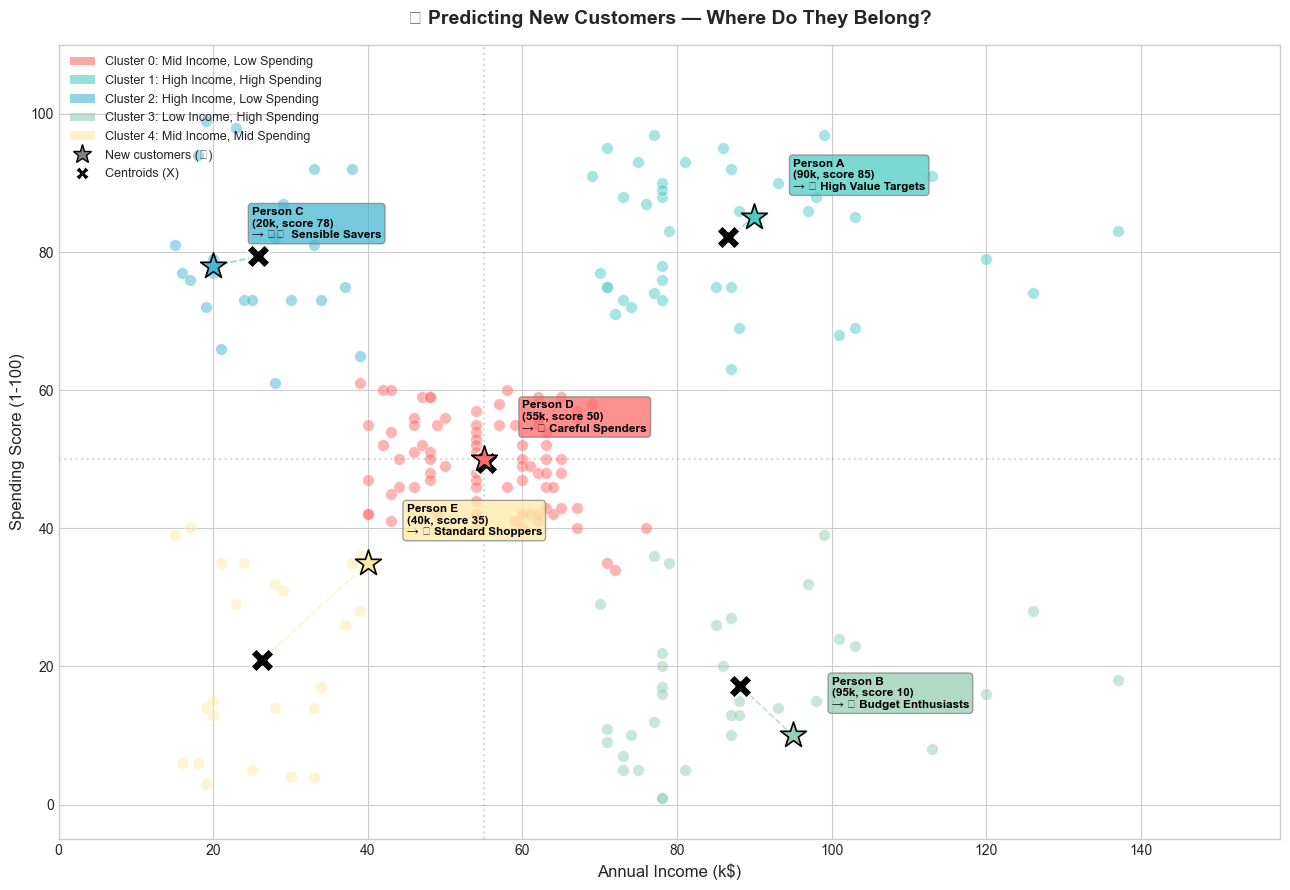

✅ Prediction plot saved as 'prediction_plot.png'


In [39]:
# ============================================================
# STEP 9c: PLOT NEW CUSTOMERS ON THE CLUSTER MAP
# Stars (★) = new customers being predicted
# Dots       = original trained customers
# ============================================================

# Define new customers to predict and visualise
new_customers_list = [
    {'label': 'Person A\n(90k, score 85)',  'income': 90,  'spending': 85},
    {'label': 'Person B\n(95k, score 10)',  'income': 95,  'spending': 10},
    {'label': 'Person C\n(20k, score 78)',  'income': 20,  'spending': 78},
    {'label': 'Person D\n(55k, score 50)',  'income': 55,  'spending': 50},
    {'label': 'Person E\n(40k, score 35)',  'income': 40,  'spending': 35},
]

cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

fig, ax = plt.subplots(figsize=(13, 9))

# ── Plot the original trained clusters (background) ──────────────────────────
for i in range(OPTIMAL_K):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score (1-100)'],
               c=cluster_colors[i], s=70, alpha=0.5,
               edgecolors='white', linewidths=0.5, zorder=2)

# ── Plot cluster centroids ────────────────────────────────────────────────────
ax.scatter(centroids_original[:, 0], centroids_original[:, 1],
           s=300, c='black', marker='X', zorder=4,
           label='Centroids', edgecolors='white', linewidths=1.5)

# ── Plot and annotate each new customer ──────────────────────────────────────
for person in new_customers_list:
    # Predict silently (verbose=False so no text printed here)
    result = predict_customer(person['income'], person['spending'], verbose=False)
    cid    = result['cluster_id']
    color  = cluster_colors[cid]

    # Plot the new customer as a large star
    ax.scatter(person['income'], person['spending'],
               s=380, marker='*', color=color, zorder=6,
               edgecolors='black', linewidths=1.2)

    # Draw a dashed line from the new customer to their centroid
    cx, cy = centroids_original[cid]
    ax.plot([person['income'], cx], [person['spending'], cy],
            '--', color=color, alpha=0.6, linewidth=1.2, zorder=3)

    # Annotate with person label and predicted cluster
    ax.annotate(
        f"{person['label']}\n→ {cluster_names[cid].split('(')[0].strip()}",
        xy=(person['income'], person['spending']),
        xytext=(person['income'] + 5, person['spending'] + 4),
        fontsize=8.5, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                  alpha=0.75, edgecolor='gray'),
        zorder=7
    )

# ── Legend for clusters ───────────────────────────────────────────────────────
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=cluster_colors[i], alpha=0.6,
          label=f'Cluster {i}: {cluster_names[i].split("(")[1].rstrip(")")}')
    for i in range(OPTIMAL_K)
]
legend_elements += [
    Line2D([0],[0], marker='*', color='w', markerfacecolor='gray',
           markersize=14, markeredgecolor='black', label='New customers (★)'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='black',
           markersize=10, label='Centroids (X)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

ax.set_title('🔮 Predicting New Customers — Where Do They Belong?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.3)
ax.axvline(x=55, color='gray', linestyle=':', alpha=0.3)
ax.set_xlim(0, 158)
ax.set_ylim(-5, 110)

plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prediction plot saved as 'prediction_plot.png'")


---

## 9d. Batch Prediction — Predict Many Customers at Once

In the real world you will often receive a **list of new customers** (e.g. from a sign-up form or a CSV file).  
We can predict all of them at once — much faster than one at a time.


In [40]:
# ============================================================
# STEP 9d: BATCH PREDICTION
# Predict cluster for a whole table of new customers at once
# This is the real-world, production-ready approach!
# ============================================================

# ── Create a batch of new customers ──────────────────────────────────────────
new_customers_batch = pd.DataFrame({
    'Name':                   ['Ali',    'Sara',   'Ahmed',  'Maria',  'Usman',  'Zara',   'Hassan', 'Ayesha'],
    'Annual Income (k$)':     [88,       22,       60,       110,      35,       75,       45,       130    ],
    'Spending Score (1-100)': [82,       90,       48,       15,       25,       72,       55,       10     ],
})

print("📋 New customers to predict:")
print(new_customers_batch.to_string(index=False))
print()

# ── Step 1: Extract only the feature columns ─────────────────────────────────
X_new = new_customers_batch[['Annual Income (k$)', 'Spending Score (1-100)']]

# ── Step 2: Scale using the ALREADY FITTED scaler ────────────────────────────
# .transform() — NOT .fit_transform() — applies the same scaling as training
X_new_scaled = scaler.transform(X_new)

# ── Step 3: Predict clusters for all customers at once ───────────────────────
predicted_clusters = kmeans_final.predict(X_new_scaled)

# ── Step 4: Add predictions to the DataFrame ────────────────────────────────
new_customers_batch['Predicted_Cluster']      = predicted_clusters
new_customers_batch['Predicted_Segment']      = new_customers_batch['Predicted_Cluster'].map(cluster_names)

# ── Step 5: Display the results ──────────────────────────────────────────────
print("✅ Batch prediction complete!")
print("\n🎯 Predicted Segments:")
print("-" * 90)
for _, row in new_customers_batch.iterrows():
    print(f"  {row['Name']:<8} | Income: {row['Annual Income (k$)']:>4}k "
          f"| Score: {row['Spending Score (1-100)']:>3} "
          f"| Cluster {row['Predicted_Cluster']} → {row['Predicted_Segment']}")
print("-" * 90)

# ── Step 6: Summary count ────────────────────────────────────────────────────
print("\n📊 Segment Distribution in Batch:")
seg_counts = new_customers_batch['Predicted_Segment'].value_counts()
for seg, count in seg_counts.items():
    bar = '█' * count
    print(f"  {seg[:45]:<45} : {count} {bar}")


📋 New customers to predict:
  Name  Annual Income (k$)  Spending Score (1-100)
   Ali                  88                      82
  Sara                  22                      90
 Ahmed                  60                      48
 Maria                 110                      15
 Usman                  35                      25
  Zara                  75                      72
Hassan                  45                      55
Ayesha                 130                      10

✅ Batch prediction complete!

🎯 Predicted Segments:
------------------------------------------------------------------------------------------
  Ali      | Income:   88k | Score:  82 | Cluster 1 → 💜 High Value Targets (High Income, High Spending)
  Sara     | Income:   22k | Score:  90 | Cluster 2 → ❤️  Sensible Savers (High Income, Low Spending)
  Ahmed    | Income:   60k | Score:  48 | Cluster 0 → 💛 Careful Spenders (Mid Income, Low Spending)
  Maria    | Income:  110k | Score:  15 | Cluster 3 → 💚 Budget 

---

## 9e. Save the Model — Use It Later Without Retraining

Training takes time. In real projects, we **save the trained model to disk** so we can reload it anytime and make predictions instantly — without running all the previous cells again.

We use Python's `joblib` library (built for saving sklearn models efficiently).

```
Training (done once)          Prediction (done anytime)
─────────────────────         ─────────────────────────
Load data                     Load saved model  ← fast!
Train model      → save  →    Load saved scaler ← fast!
Fit scaler                    New customer data
                              Predict cluster   ← instant!
```


In [41]:
# ============================================================
# STEP 9e: SAVE THE TRAINED MODEL AND SCALER TO DISK
# joblib is the standard way to save sklearn models
# ============================================================

import joblib   # Part of scikit-learn — for saving/loading models

# ── Save the trained K-Means model ───────────────────────────────────────────
# This saves all the centroid positions the model learned
joblib.dump(kmeans_final, 'kmeans_mall_model.pkl')
print("💾 K-Means model saved  → 'kmeans_mall_model.pkl'")

# ── Save the fitted scaler ────────────────────────────────────────────────────
# This saves the mean and std values the scaler learned from training data
# CRITICAL: must save this too — or new predictions will be scaled wrong!
joblib.dump(scaler, 'scaler_mall.pkl')
print("💾 Scaler saved         → 'scaler_mall.pkl'")

# ── Save the cluster names dictionary ────────────────────────────────────────
joblib.dump(cluster_names, 'cluster_names_mall.pkl')
print("💾 Cluster names saved  → 'cluster_names_mall.pkl'")

print("\n✅ Everything needed for prediction is saved!")
print("\n📁 Files created:")
print("   kmeans_mall_model.pkl   ← the trained K-Means model")
print("   scaler_mall.pkl         ← the fitted StandardScaler")
print("   cluster_names_mall.pkl  ← the cluster name labels")


💾 K-Means model saved  → 'kmeans_mall_model.pkl'
💾 Scaler saved         → 'scaler_mall.pkl'
💾 Cluster names saved  → 'cluster_names_mall.pkl'

✅ Everything needed for prediction is saved!

📁 Files created:
   kmeans_mall_model.pkl   ← the trained K-Means model
   scaler_mall.pkl         ← the fitted StandardScaler
   cluster_names_mall.pkl  ← the cluster name labels


In [ ]:
# ============================================================
# STEP 9f: RELOAD AND USE THE SAVED MODEL
# Simulate loading the model in a fresh session (no retraining!)
# ============================================================

# ── Load everything back from disk ───────────────────────────────────────────
loaded_model        = joblib.load('kmeans_mall_model.pkl')
loaded_scaler       = joblib.load('scaler_mall.pkl')
loaded_cluster_names = joblib.load('cluster_names_mall.pkl')

print("✅ Model, scaler and cluster names loaded from disk!")
print(f"   Model type   : {type(loaded_model).__name__}")
print(f"   Scaler type  : {type(loaded_scaler).__name__}")
print(f"   Cluster names: {list(loaded_cluster_names.keys())}")

# ── Make a prediction using ONLY the loaded model (no retraining!) ───────────
print("\n🔮 Predicting with the loaded model (not the trained one):")
print("-" * 50)

test_person = pd.DataFrame({
    'Annual Income (k$)':    [70],
    'Spending Score (1-100)': [90]
})

# Scale using loaded scaler
test_scaled = loaded_scaler.transform(test_person)

# Predict using loaded model
pred_cluster = loaded_model.predict(test_scaled)[0]
pred_name    = loaded_cluster_names[pred_cluster]

print(f"  New customer → Income: $70k | Spending Score: 90")
print(f"  Predicted cluster  : {pred_cluster}")
print(f"  Predicted segment  : {pred_name}")
print("-" * 50)
print("\n💡 This works even if you restart Python and run ONLY this cell!")


---

## 9g. Interactive Prediction — Try Your Own Values!

Now you can predict any customer interactively.  
Just change the values in the cell below and run it!


In [43]:
# ============================================================
# STEP 9g: INTERACTIVE PREDICTION — CHANGE THESE VALUES!
# ============================================================
# ↓↓↓ STUDENTS: Edit these two values and run the cell ↓↓↓

MY_INCOME        = 60    # Annual income in k$ (e.g. 60 means $60,000)
MY_SPENDING_SCORE = 70   # Spending score from 1 to 100

# ↑↑↑ ---------------------------------------------------↑↑↑

# Run the prediction
result = predict_customer(
    annual_income   = MY_INCOME,
    spending_score  = MY_SPENDING_SCORE
)

# ── Visualise this single prediction on the cluster map ──────────────────────


       🔮 CUSTOMER SEGMENT PREDICTION
  💰 Annual Income   : $60k
  🛒 Spending Score  : 70/100
  🏷️  Cluster ID     : 0
  📌 Segment         : 💛 Careful Spenders (Mid Income, Low Spending)

📍 Distance to each cluster centroid:
---------------------------------------------
  Cluster 0 | Income:  55.3k  Score: 49.5 | dist=  21.0 ← NEAREST (predicted)
  Cluster 1 | Income:  86.5k  Score: 82.1 | dist=  29.2
  Cluster 2 | Income:  25.7k  Score: 79.4 | dist=  35.5
  Cluster 3 | Income:  88.2k  Score: 17.1 | dist=  59.9
  Cluster 4 | Income:  26.3k  Score: 20.9 | dist=  59.5
---------------------------------------------


---

## 📋 Prediction Summary

### What You Learned in Step 9

| Sub-step | What We Did |
|----------|-------------|
| 9a | Built a `predict_customer()` function with input validation and distance display |
| 9b | Predicted individual customers and understood WHY each was assigned to a cluster |
| 9c | Visualised new customers plotted on the cluster map with dashed lines to centroids |
| 9d | Ran **batch prediction** on a table of 8 new customers at once |
| 9e | Saved the model, scaler, and cluster names to `.pkl` files using `joblib` |
| 9f | Reloaded the saved model and made predictions without retraining |
| 9g | Built an **interactive prediction cell** — just change income and score and run! |

---

### ⚠️ The Most Important Rule in Prediction

> **Always use `scaler.transform()` on new data — never `scaler.fit_transform()`!**
>
> `fit_transform()` learns new mean/std from the new data — this breaks consistency with training.  
> `transform()` applies the SAME statistics that were learned during training — this is correct.

---

### 🔧 Real-World Pipeline

```python
# One-time training (run once, save to disk)
scaler       = StandardScaler().fit(X_train)
kmeans_model = KMeans(n_clusters=5).fit(scaler.transform(X_train))
joblib.dump(kmeans_model, 'model.pkl')
joblib.dump(scaler,       'scaler.pkl')

# Production prediction (run anytime, no retraining)
model  = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')
cluster = model.predict(scaler.transform(new_data))
```
